In [63]:
import pandas as pd

In [87]:
path = "../../datamart/gold/combined/gold_combined_oot_2025_01_01.parquet"
df_oot = pd.read_parquet(path)  # requires pyarrow or fastparquet

In [88]:
df_oot['FlightDate'] = df_oot['snapshot_date'].astype('object')

In [74]:
df_oot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   flight_id                        1020 non-null   object 
 1   OP_UNIQUE_CARRIER                1020 non-null   object 
 2   ORIGIN                           1020 non-null   object 
 3   YEAR                             1020 non-null   int32  
 4   MONTH                            1020 non-null   int32  
 5   DAY_OF_MONTH                     1020 non-null   int32  
 6   OP_CARRIER_FL_NUM                1020 non-null   int32  
 7   ORIGIN_AIRPORT_ID                1020 non-null   int32  
 8   ORIGIN_CITY_NAME                 1020 non-null   object 
 9   ORIGIN_STATE_ABR                 1020 non-null   object 
 10  DEST_AIRPORT_ID                  1020 non-null   int32  
 11  DEST                             1020 non-null   object 
 12  DEST_CITY_NAME      

In [62]:
print(df_oot.head())

  flight_id OP_UNIQUE_CARRIER ORIGIN  YEAR  MONTH  DAY_OF_MONTH  \
0     AA_76                AA    JFK  2025      1             1   
1    AA_171                AA    JFK  2025      1             1   
2    AA_655                AA    JFK  2025      1             1   
3   AA_2643                AA    JFK  2025      1             1   
4      AA_1                AA    JFK  2025      1             1   

   OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID ORIGIN_CITY_NAME ORIGIN_STATE_ABR  \
0                 76              12478     New York, NY               NY   
1                171              12478     New York, NY               NY   
2                655              12478     New York, NY               NY   
3               2643              12478     New York, NY               NY   
4                  1              12478     New York, NY               NY   

   ...  weather_ceiling_m weather_ceiling_code weather_visibility_m  \
0  ...            22000.0                    9              160

In [53]:
df_oot['snapshot_date']

0       2025-01-01
1       2025-01-01
2       2025-01-01
3       2025-01-01
4       2025-01-01
           ...    
1015    2025-01-01
1016    2025-01-01
1017    2025-01-01
1018    2025-01-01
1019    2025-01-01
Name: snapshot_date, Length: 1020, dtype: category
Categories (1, object): ['2025-01-01']

In [69]:
path = "../../datamart/gold/gold_combined_historical.parquet/snapshot_date=2023-01-01"
df = pd.read_parquet(path)  # requires pyarrow or fastparquet

In [56]:
print(df.shape)
df['FlightDate'].head(100)

(1053, 54)


0     2023-01-01
1     2023-01-01
2     2023-01-01
3     2023-01-01
4     2023-01-01
         ...    
95    2023-01-01
96    2023-01-01
97    2023-01-01
98    2023-01-01
99    2023-01-01
Name: FlightDate, Length: 100, dtype: object

In [70]:
# Print DataFrame info (as you already do)
print("\nCombined DataFrame Info:")
print(df.info())

# Select columns whose names contain 'DELAY' (case-insensitive)
delay_cols = [col for col in df.columns if 'DELAY' in col.upper()]

print("\nColumns containing 'DELAY':")
print(delay_cols)

# Optionally display the first few rows for those columns
print("\nSample values for delay-related columns:")
print(df[delay_cols].head())


Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   flight_id                        1053 non-null   object 
 1   OP_UNIQUE_CARRIER                1053 non-null   object 
 2   ORIGIN                           1053 non-null   object 
 3   YEAR                             1053 non-null   int32  
 4   MONTH                            1053 non-null   int32  
 5   DAY_OF_MONTH                     1053 non-null   int32  
 6   OP_CARRIER_FL_NUM                1053 non-null   int32  
 7   ORIGIN_AIRPORT_ID                1053 non-null   int32  
 8   ORIGIN_CITY_NAME                 1053 non-null   object 
 9   ORIGIN_STATE_ABR                 1053 non-null   object 
 10  DEST_AIRPORT_ID                  1053 non-null   int32  
 11  DEST                             1053 non-null   object 

In [21]:
# Print DataFrame info (as you already do)
print("\nCombined DataFrame Info:")
print(df.info())

# Define the columns to exclude
exclude_cols = [
    "DEP_DELAY_NEW", "DEP_DELAY_GROUP", "ARR_DELAY_NEW", "ARR_DELAY_GROUP",
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    # ---- weather cleanup ----
    "weather_ceiling_code", "weather_visibility_var_code_idx",
    "weather_wind_dir_deg", "weather_visibility_var_code"
]

# Drop those columns safely if they exist
df_excluded = df.drop(columns=[c for c in exclude_cols if c in df.columns], errors="ignore")

print("\nExcluded columns:")
print([c for c in exclude_cols if c in df.columns])

print("\nRemaining columns:")
print(df_excluded.columns.tolist())

# Optional: show sample rows of the cleaned DataFrame
print("\nCleaned DataFrame preview:")
print(df_excluded.head())



Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   flight_id                        1053 non-null   object 
 1   OP_UNIQUE_CARRIER                1053 non-null   object 
 2   ORIGIN                           1053 non-null   object 
 3   YEAR                             1053 non-null   int32  
 4   MONTH                            1053 non-null   int32  
 5   DAY_OF_MONTH                     1053 non-null   int32  
 6   OP_CARRIER_FL_NUM                1053 non-null   int32  
 7   ORIGIN_AIRPORT_ID                1053 non-null   int32  
 8   ORIGIN_CITY_NAME                 1053 non-null   object 
 9   ORIGIN_STATE_ABR                 1053 non-null   object 
 10  DEST_AIRPORT_ID                  1053 non-null   int32  
 11  DEST                             1053 non-null   object 


Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   flight_id                        1053 non-null   object 
 1   OP_UNIQUE_CARRIER                1053 non-null   object 
 2   ORIGIN                           1053 non-null   object 
 3   YEAR                             1053 non-null   int32  
 4   MONTH                            1053 non-null   int32  
 5   DAY_OF_MONTH                     1053 non-null   int32  
 6   OP_CARRIER_FL_NUM                1053 non-null   int32  
 7   ORIGIN_AIRPORT_ID                1053 non-null   int32  
 8   ORIGIN_CITY_NAME                 1053 non-null   object 
 9   ORIGIN_STATE_ABR                 1053 non-null   object 
 10  DEST_AIRPORT_ID                  1053 non-null   int32  
 11  DEST                             1053 non-null   object 

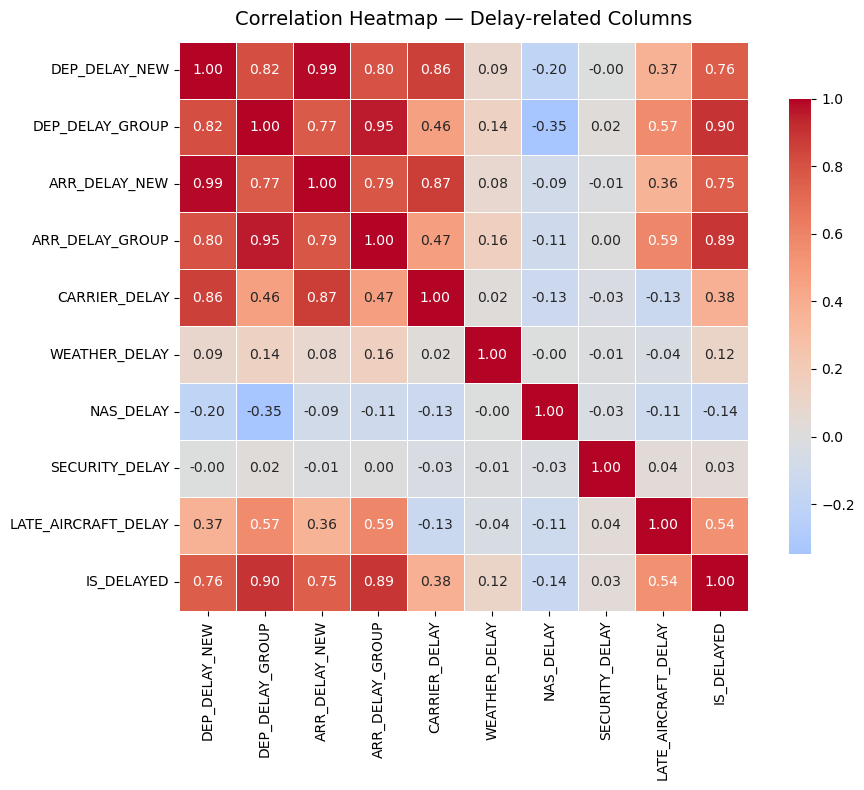


Numeric columns (39):
['YEAR', 'MONTH', 'DAY_OF_MONTH', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY_NEW', 'DEP_DELAY_GROUP', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY_NEW', 'ARR_DELAY_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DayOfWeek', 'IsWeekend', 'IsPublicHoliday', 'IS_DELAYED', 'daily_flights', 'volume_zscore', 'is_rare', 'is_abnormal_num', 'is_peak_day', 'is_extra_candidate', 'weather_wind_dir_deg', 'weather_wind_type', 'weather_wind_speed_mps', 'weather_ceiling_m', 'weather_ceiling_code', 'weather_visibility_m', 'weather_temp_c', 'weather_dewpoint_c', 'weather_slp_hpa', 'weather_visibility_var_code_idx']


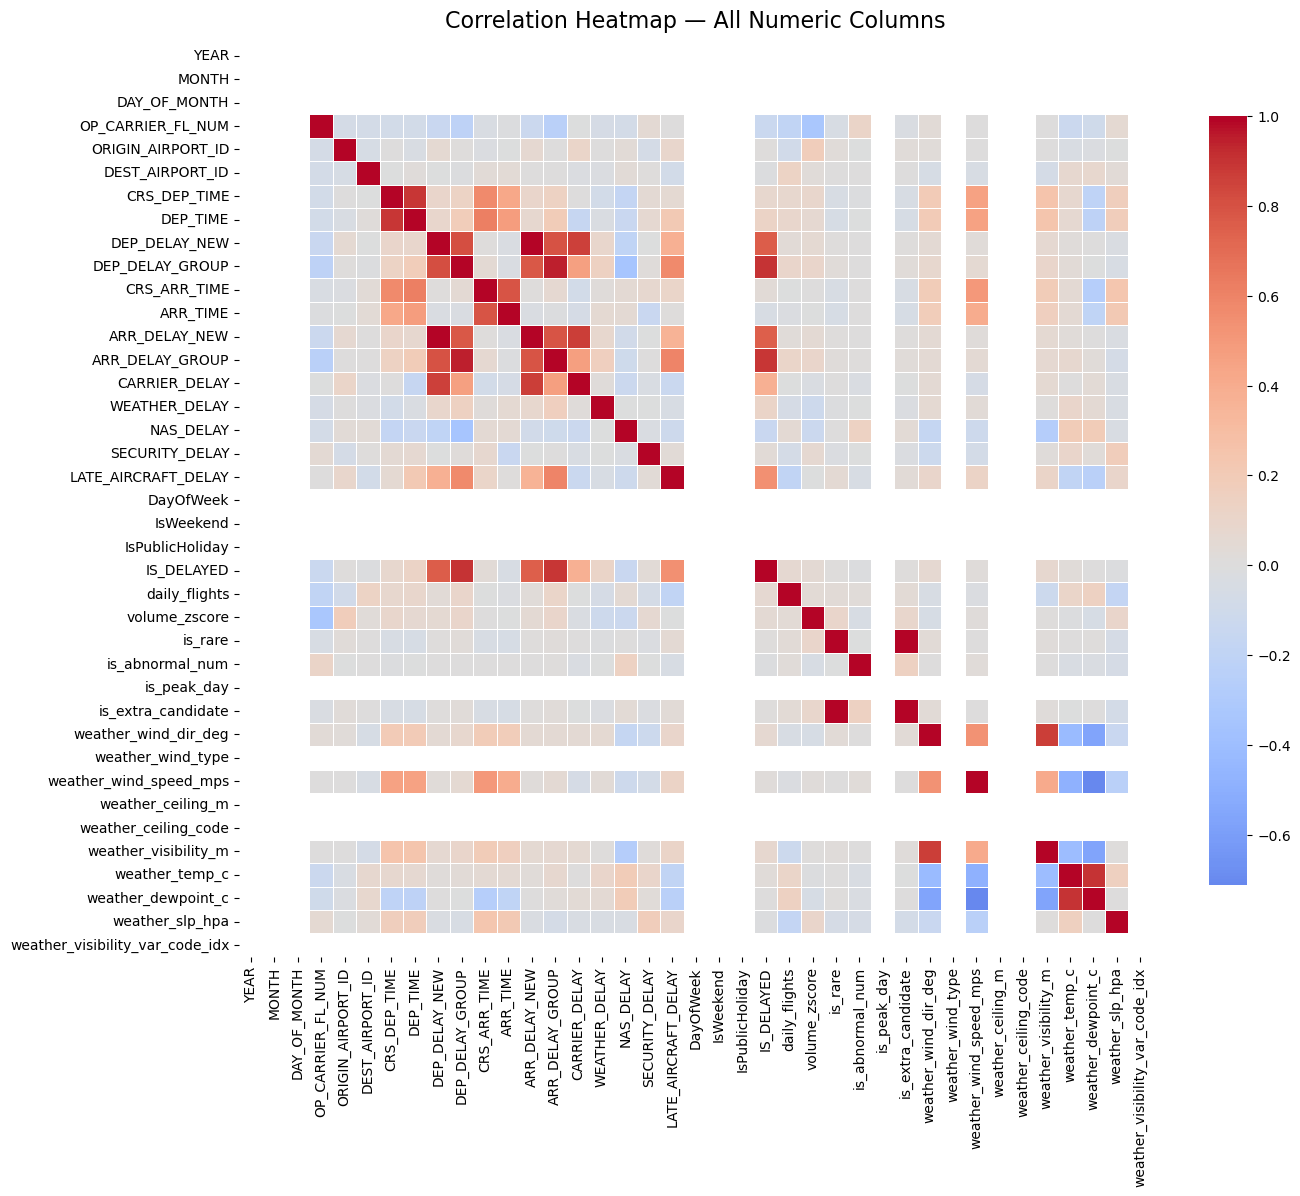

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print DataFrame info (as you already do)
print("\nCombined DataFrame Info:")
print(df.info())

# Select columns whose names contain 'DELAY' (case-insensitive)
delay_cols = [col for col in df.columns if 'DELAY' in col.upper()]
print("\nColumns containing 'DELAY':")
print(delay_cols)

print("\nSample values for delay-related columns:")
print(df[delay_cols].head())

# ---------------------------------------------------------------
# 1️⃣ Correlation Heatmap — Delay-related columns
# ---------------------------------------------------------------
if delay_cols:
    delay_df = df[delay_cols].apply(pd.to_numeric, errors='coerce')
    corr_delay = delay_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_delay,
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Correlation Heatmap — Delay-related Columns", fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()
else:
    print("No columns containing 'DELAY' found.")

# ---------------------------------------------------------------
# 2️⃣ Correlation Heatmap — All numeric columns
# ---------------------------------------------------------------
numeric_df = df.select_dtypes(include=["number", "bool"]).copy()
numeric_df["IsWeekend"] = pd.to_numeric(df["IsWeekend"], errors="coerce").fillna(0)
print(f"\nNumeric columns ({len(numeric_df.columns)}):")
print(numeric_df.columns.tolist())

if len(numeric_df.columns) > 1:
    corr_all = numeric_df.corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr_all,
        cmap="coolwarm",
        center=0,
        square=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Correlation Heatmap — All Numeric Columns", fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")
